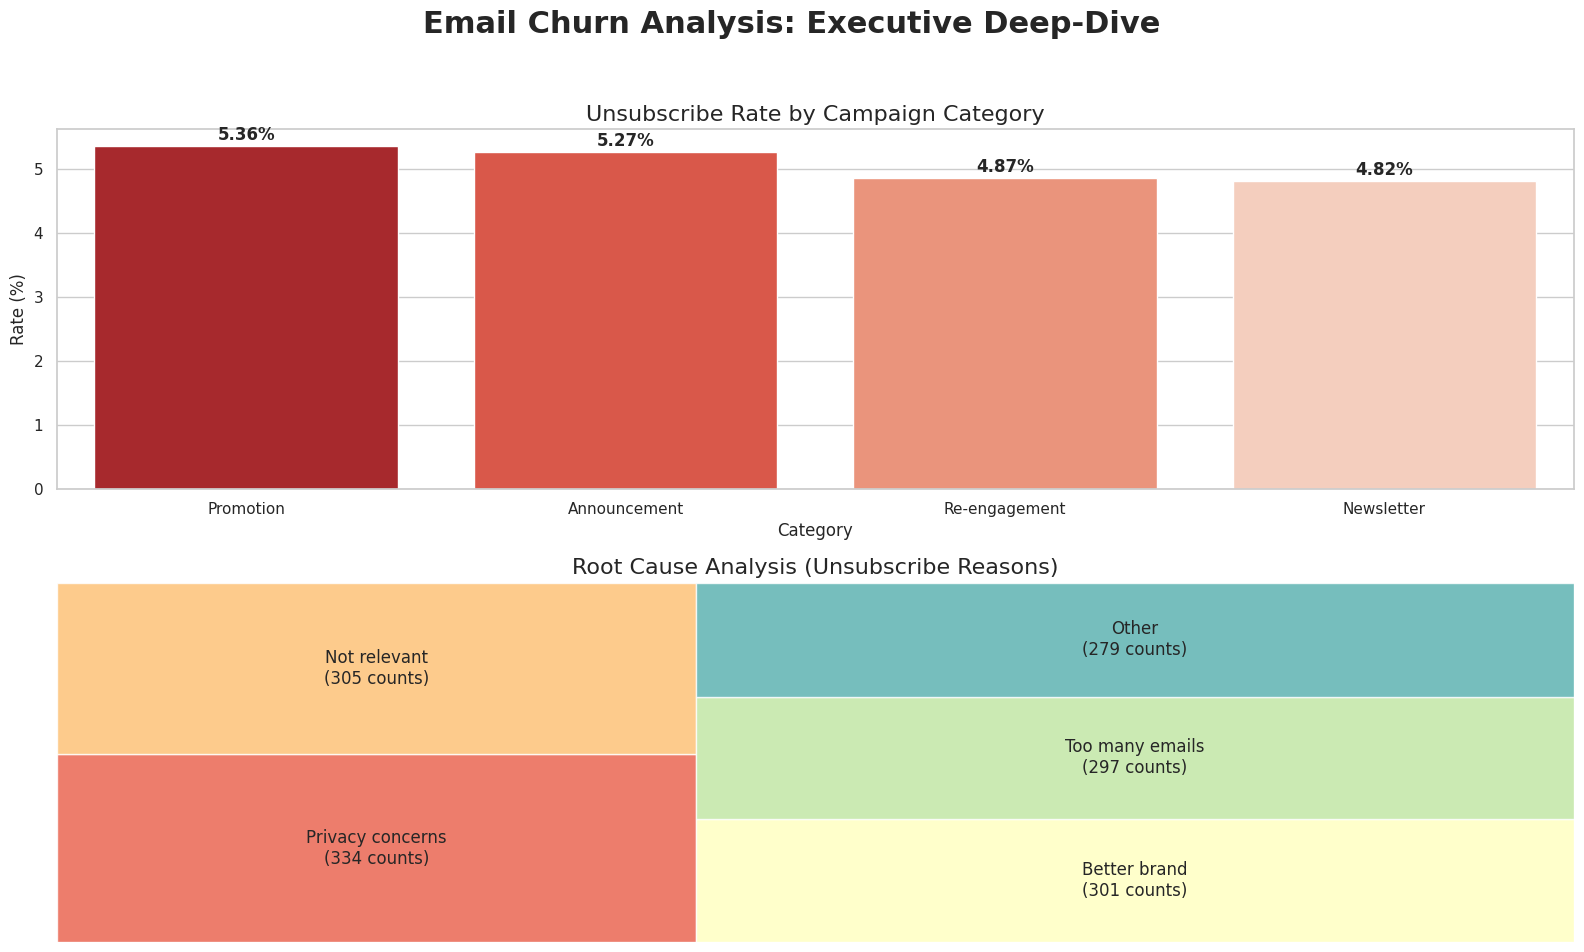

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
!pip install squarify
import squarify # You may need to !pip install squarify

# 1. Setup Dataframes from your SQL Results
# Category Data
df_cat = pd.DataFrame({
    'Category': ['Promotion', 'Announcement', 'Re-engagement', 'Newsletter'],
    'Rate': [5.36, 5.27, 4.87, 4.82]
})

# Reasons Data
df_reasons = pd.DataFrame({
    'Reason': ['Privacy concerns', 'Not relevant', 'Better brand', 'Too many emails', 'Other'],
    'Count': [334, 305, 301, 297, 279]
})

# 2. Create the Layout
fig = plt.figure(figsize=(16, 10))
plt.suptitle('Email Churn Analysis: Executive Deep-Dive', fontsize=22, fontweight='bold', y=0.98)

# --- CHART 1: Bar Chart (Category Churn) ---
ax1 = plt.subplot(2, 1, 1)
sns.barplot(x='Category', y='Rate', data=df_cat.sort_values('Rate', ascending=False), palette='Reds_r', ax=ax1, hue='Category', legend=False)
ax1.set_title('Unsubscribe Rate by Campaign Category', fontsize=16)
ax1.set_ylabel('Rate (%)')
# Add labels [cite: 22-28]
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', weight='bold')

# --- CHART 2: Treemap (Why Users Leave) ---
# Replacing the Pie chart with an advanced Treemap
ax2 = plt.subplot(2, 1, 2)
labels = [f"{r}\n({c} counts)" for r, c in zip(df_reasons['Reason'], df_reasons['Count'])]
colors = sns.color_palette("Spectral", len(df_reasons))

squarify.plot(sizes=df_reasons['Count'], label=labels, alpha=0.8, color=colors, ax=ax2)
ax2.set_title('Root Cause Analysis (Unsubscribe Reasons)', fontsize=16)
plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipython-input-2587080778.py:40: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




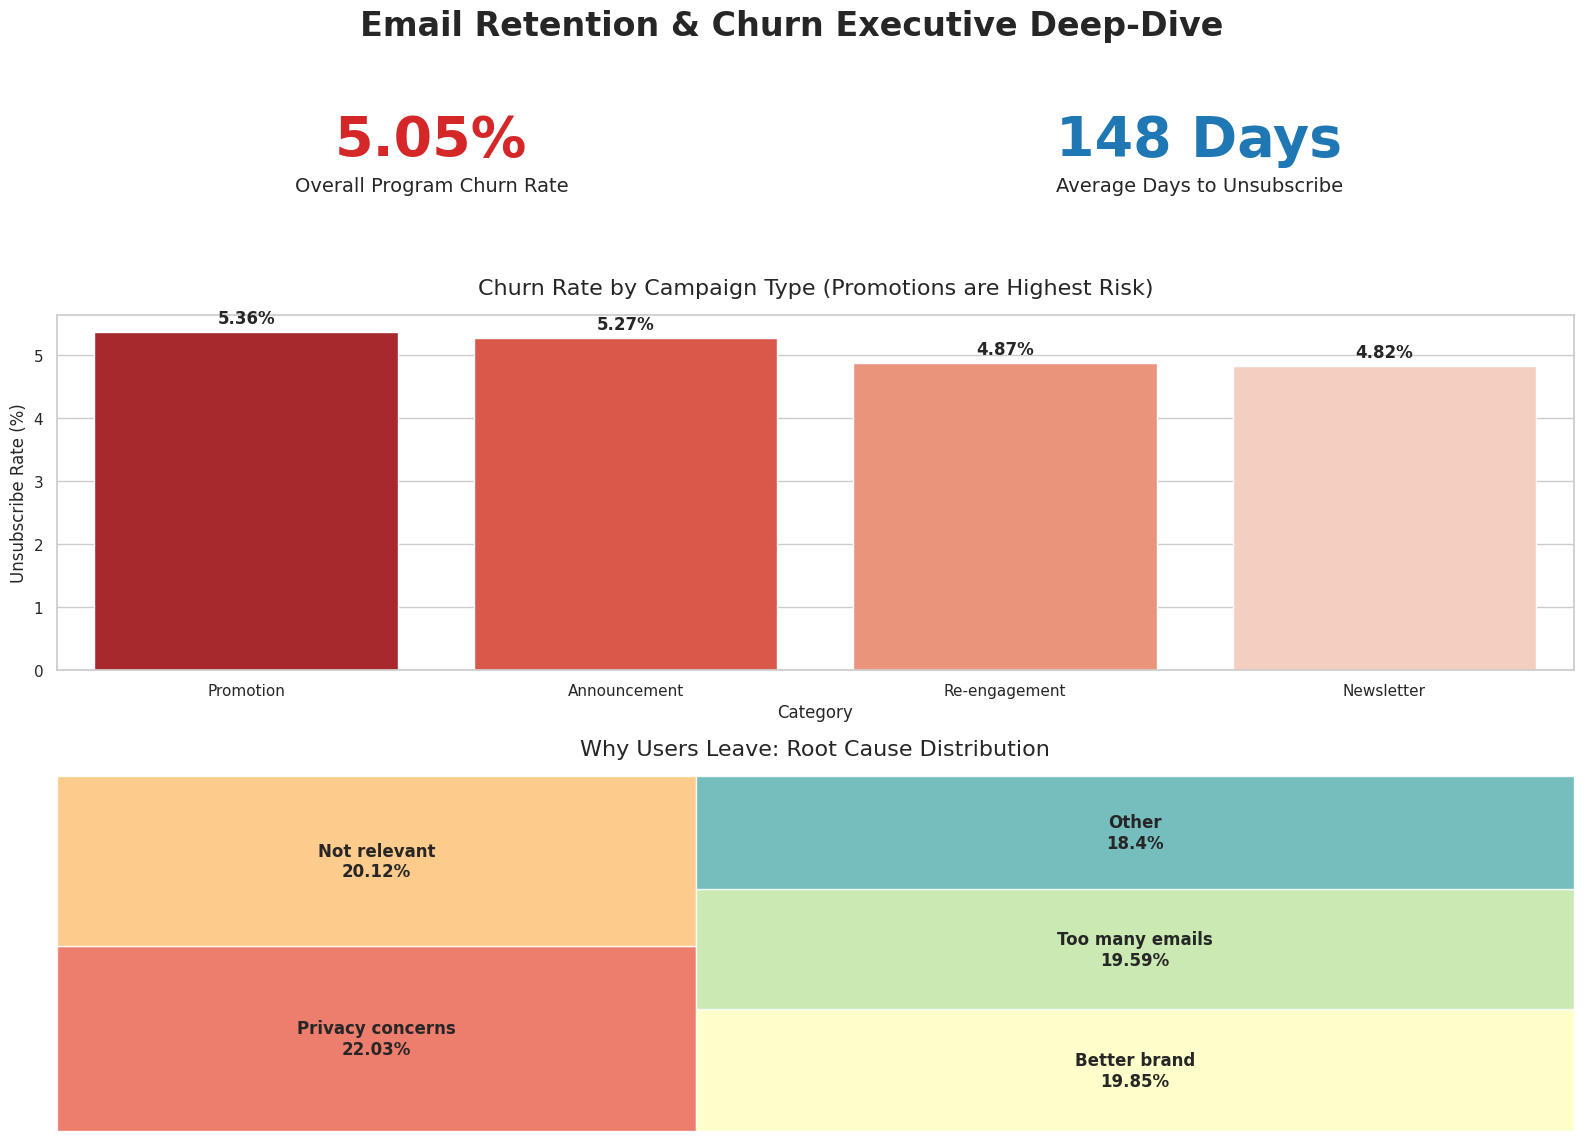

In [ ]:
____import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import squarify # You may need to run: !pip install squarify

# 1. Prepare Data from your SQL results
# Category Churn [cite: 11-28]
df_cat = pd.DataFrame({
    'Category': ['Promotion', 'Announcement', 'Re-engagement', 'Newsletter'],
    'Rate': [5.36, 5.27, 4.87, 4.82]
}).sort_values('Rate', ascending=False)

# Unsubscribe Reasons
df_reasons = pd.DataFrame({
    'Reason': ['Privacy concerns', 'Not relevant', 'Better brand', 'Too many emails', 'Other'],
    'Count': [334, 305, 301, 297, 279],
    'Percent': ['22.03%', '20.12%', '19.85%', '19.59%', '18.4%']
})

# 2. Setup Figure and Layout (GridSpec for advanced positioning)
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 4, 4])
plt.suptitle('Email Retention & Churn Executive Deep-Dive', fontsize=24, fontweight='bold', y=0.98)

# --- SECTION 1: KPI Cards (The "Big Numbers") ---
# Card 1: Overall Churn [cite: 5]
ax0 = fig.add_subplot(gs[0, 0])
ax0.text(0.5, 0.6, '5.05%', fontsize=40, fontweight='bold', ha='center', color='#d62728')
ax0.text(0.5, 0.2, 'Overall Program Churn Rate', fontsize=14, ha='center')
ax0.axis('off')

# Card 2: Timing [cite: 31-32]
ax1 = fig.add_subplot(gs[0, 1])
ax1.text(0.5, 0.6, '148 Days', fontsize=40, fontweight='bold', ha='center', color='#1f77b4')
ax1.text(0.5, 0.2, 'Average Days to Unsubscribe', fontsize=14, ha='center')
ax1.axis('off')

# --- SECTION 2: Category Churn (Bar Chart) [cite: 11-28] ---
ax2 = fig.add_subplot(gs[1, :])
sns.barplot(x='Category', y='Rate', data=df_cat, palette='Reds_r', ax=ax2)
ax2.set_title('Churn Rate by Campaign Type (Promotions are Highest Risk)', fontsize=16, pad=15)
ax2.set_ylabel('Unsubscribe Rate (%)')
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', weight='bold')

# --- SECTION 3: Root Cause Analysis (Advanced Treemap)  ---
ax3 = fig.add_subplot(gs[2, :])
labels = [f"{r}\n{p}" for r, p in zip(df_reasons['Reason'], df_reasons['Percent'])]
squarify.plot(sizes=df_reasons['Count'], label=labels, alpha=0.8,
               color=sns.color_palette("Spectral", len(df_reasons)), ax=ax3, text_kwargs={'fontsize':12, 'weight':'bold'})
ax3.set_title('Why Users Leave: Root Cause Distribution', fontsize=16, pad=15)
ax3.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()